ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

![step1.png](attachment:step1.png)

In [556]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [557]:
#print the path of the dataset
import kagglehub

path = kagglehub.dataset_download("nayakganesh007/nike-sales-uncleaned-dataset")
print("Path:", path)

Using Colab cache for faster access to the 'nike-sales-uncleaned-dataset' dataset.
Path: /kaggle/input/nike-sales-uncleaned-dataset


In [558]:
# Load Dataset
df = pd.read_csv("/kaggle/input/nike-sales-uncleaned-dataset/Nike_Sales_Uncleaned.csv")

# Display first 5 rows. If you want to display all rows, use df.head(-1)
df.head(-1)

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024/09/12,Retail,Delhi,187.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2494,4494,Women,Training,ZoomX Invincible,L,NaN,NaN,NaN,0.0,12-02-2025,Online,Kolkata,1357.29
2495,4495,Kids,Basketball,Kyrie Flytrap,XL,3.0,NaN,NaN,0.0,2025-05-14,Online,Pune,2.97
2496,4496,Men,Basketball,Kyrie Flytrap,L,-1.0,NaN,NaN,0.0,NaN,Online,Hyd,-487.36
2497,4497,Men,Soccer,Tiempo Legend,7,NaN,6647.60,0.52,0.0,02-07-2025,Retail,Bangalore,-918.14


In [559]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Gender_Category   2500 non-null   object 
 2   Product_Line      2500 non-null   object 
 3   Product_Name      2500 non-null   object 
 4   Size              1990 non-null   object 
 5   Units_Sold        1265 non-null   float64
 6   MRP               1246 non-null   float64
 7   Discount_Applied  832 non-null    float64
 8   Revenue           2500 non-null   float64
 9   Order_Date        1884 non-null   object 
 10  Sales_Channel     2500 non-null   object 
 11  Region            2500 non-null   object 
 12  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 254.0+ KB


### Check Missing Values

In [560]:
# Check all values
print(df.isna())

      Order_ID  Gender_Category  Product_Line  Product_Name   Size  \
0        False            False         False         False  False   
1        False            False         False         False  False   
2        False            False         False         False  False   
3        False            False         False         False  False   
4        False            False         False         False  False   
...        ...              ...           ...           ...    ...   
2495     False            False         False         False  False   
2496     False            False         False         False  False   
2497     False            False         False         False  False   
2498     False            False         False         False   True   
2499     False            False         False         False  False   

      Units_Sold    MRP  Discount_Applied  Revenue  Order_Date  Sales_Channel  \
0           True   True             False    False       False          False 

# Check Missing Data

In [561]:
print(df.isna().sum())

Order_ID               0
Gender_Category        0
Product_Line           0
Product_Name           0
Size                 510
Units_Sold          1235
MRP                 1254
Discount_Applied    1668
Revenue                0
Order_Date           616
Sales_Channel          0
Region                 0
Profit                 0
dtype: int64


# Check duplicate rows

In [562]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

,0


### No. of rows and columns

In [563]:
#number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (2500, 13) 

number of rows:  2500
number of columns:  13


### Data type of columns

In [564]:
# viewing the data types of columns
df.dtypes

,0
Order_ID,int64
Gender_Category,object
Product_Line,object
Product_Name,object
Size,object
Units_Sold,float64
MRP,float64
Discount_Applied,float64
Revenue,float64
Order_Date,object


# Data Before cleaning:

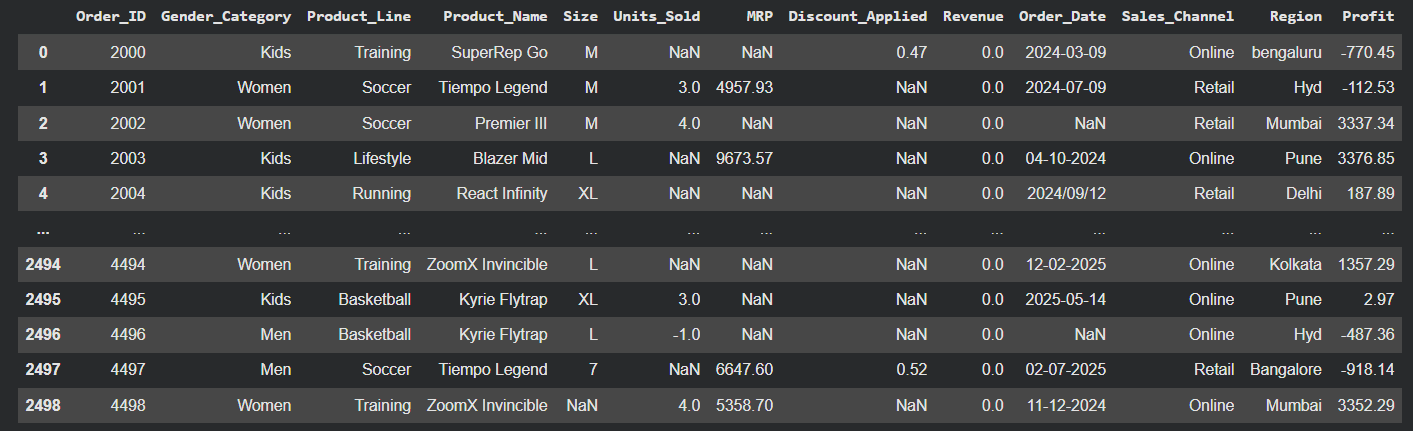

# CLEANING FOR MISSING VALUES...

In [565]:
# Make a copy before cleaning
df_clean = df.copy()

# Drop rows where critical sales data is missing

# Units_Sold and MRP are essential for revenue calculation
df_clean = df_clean.dropna(subset=['Units_Sold', 'MRP'])

# Fill missing Discount_Applied with 0 (no discount)
df_clean['Discount_Applied'] = df_clean['Discount_Applied'].fillna(0)

# Fill missing Size with 'Not Specified'
df_clean['Size'] = df_clean['Size'].fillna('Not Specified')

#fix dataframe
df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'], dayfirst=True, errors='coerce')

## Fill missing Order_Date using mode (most common date)
df_clean['Order_Date'] = df_clean['Order_Date'].fillna(df_clean['Order_Date'].mode()[0])

#add features:
df_clean['Year'] = df_clean['Order_Date'].dt.year.astype(int)  # Convert to int, no NaN
df_clean['Month'] = df_clean['Order_Date'].dt.month

# Check remaining missing values
print("Missing values after cleaning:")
print(df_clean.isna().sum())

Missing values after cleaning:
Order_ID            0
Gender_Category     0
Product_Line        0
Product_Name        0
Size                0
Units_Sold          0
MRP                 0
Discount_Applied    0
Revenue             0
Order_Date          0
Sales_Channel       0
Region              0
Profit              0
Year                0
Month               0
dtype: int64


# Data after cleaning:

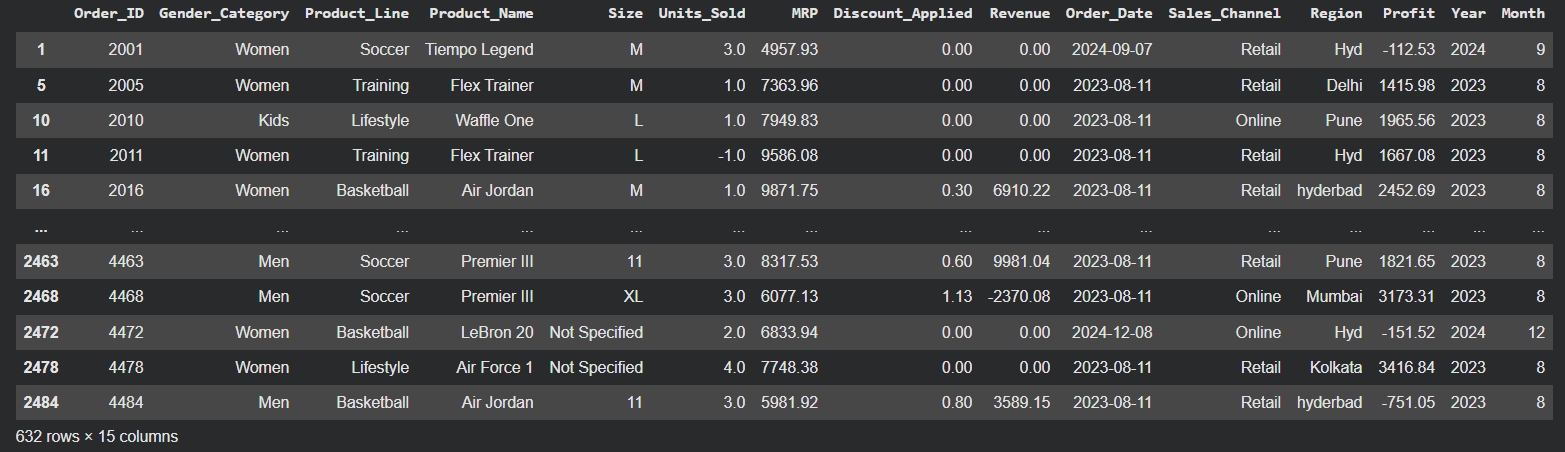

In [566]:
print(f"\n dataset: {df_clean.shape[0]} rows remaining")
df_clean.info()
df_clean.head(-1)


 dataset: 633 rows remaining
<class 'pandas.core.frame.DataFrame'>
Index: 633 entries, 1 to 2498
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          633 non-null    int64         
 1   Gender_Category   633 non-null    object        
 2   Product_Line      633 non-null    object        
 3   Product_Name      633 non-null    object        
 4   Size              633 non-null    object        
 5   Units_Sold        633 non-null    float64       
 6   MRP               633 non-null    float64       
 7   Discount_Applied  633 non-null    float64       
 8   Revenue           633 non-null    float64       
 9   Order_Date        633 non-null    datetime64[ns]
 10  Sales_Channel     633 non-null    object        
 11  Region            633 non-null    object        
 12  Profit            633 non-null    float64       
 13  Year              633 non-null    int64         
 14  

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit,Year,Month
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,0.00,0.00,2024-09-07,Retail,Hyd,-112.53,2024,9
5,2005,Women,Training,Flex Trainer,M,1.0,7363.96,0.00,0.00,2023-08-11,Retail,Delhi,1415.98,2023,8
10,2010,Kids,Lifestyle,Waffle One,L,1.0,7949.83,0.00,0.00,2023-08-11,Online,Pune,1965.56,2023,8
11,2011,Women,Training,Flex Trainer,L,-1.0,9586.08,0.00,0.00,2023-08-11,Retail,Hyd,1667.08,2023,8
16,2016,Women,Basketball,Air Jordan,M,1.0,9871.75,0.30,6910.22,2023-08-11,Retail,hyderbad,2452.69,2023,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2463,4463,Men,Soccer,Premier III,11,3.0,8317.53,0.60,9981.04,2023-08-11,Retail,Pune,1821.65,2023,8
2468,4468,Men,Soccer,Premier III,XL,3.0,6077.13,1.13,-2370.08,2023-08-11,Online,Mumbai,3173.31,2023,8
2472,4472,Women,Basketball,LeBron 20,Not Specified,2.0,6833.94,0.00,0.00,2024-12-08,Online,Hyd,-151.52,2024,12
2478,4478,Women,Lifestyle,Air Force 1,Not Specified,4.0,7748.38,0.00,0.00,2023-08-11,Retail,Kolkata,3416.84,2023,8


# BAD DATA BEFORE CLEANING...

In [567]:
# Convert Units_Sold to integer
df_clean['Units_Sold'] = df_clean['Units_Sold'].astype(int)

# Check negative and zero Units_Sold
print(f"Rows with negative or zero Units_Sold before: {(df_clean['Units_Sold'] <= 0).sum()}")

# Check discounts > 100%
print(f"Rows with discount >100% before: {(df_clean['Discount_Applied'] > 1.0).sum()}")

# Check negative or zero MRP
print(f"Rows with negative or zero MRP: {(df_clean['MRP'] <= 0).sum()}")

# Check negative revenue
print(f"Rows with negative or zero Revenue: {(df_clean['Revenue'] <= 0).sum()}")

Rows with negative or zero Units_Sold before: 213
Rows with discount >100% before: 43
Rows with negative or zero MRP: 0
Rows with negative or zero Revenue: 520


# CLEANING DATA...

In [568]:
# This removes negative values (Zero units sold means a transaction with no products, represent data entry errors)
df_clean = df_clean[df_clean['Units_Sold'] > 0]


# Remove discounts > 100%
df_clean = df_clean[df_clean['Discount_Applied'] <= 1.0]

# Remove bad Revenue
df_clean = df_clean[df_clean['Revenue'] > 0]

print(f"\n Final clean dataset: {df_clean.shape[0]} rows remaining")



 Final clean dataset: 110 rows remaining


# Data after cleaning

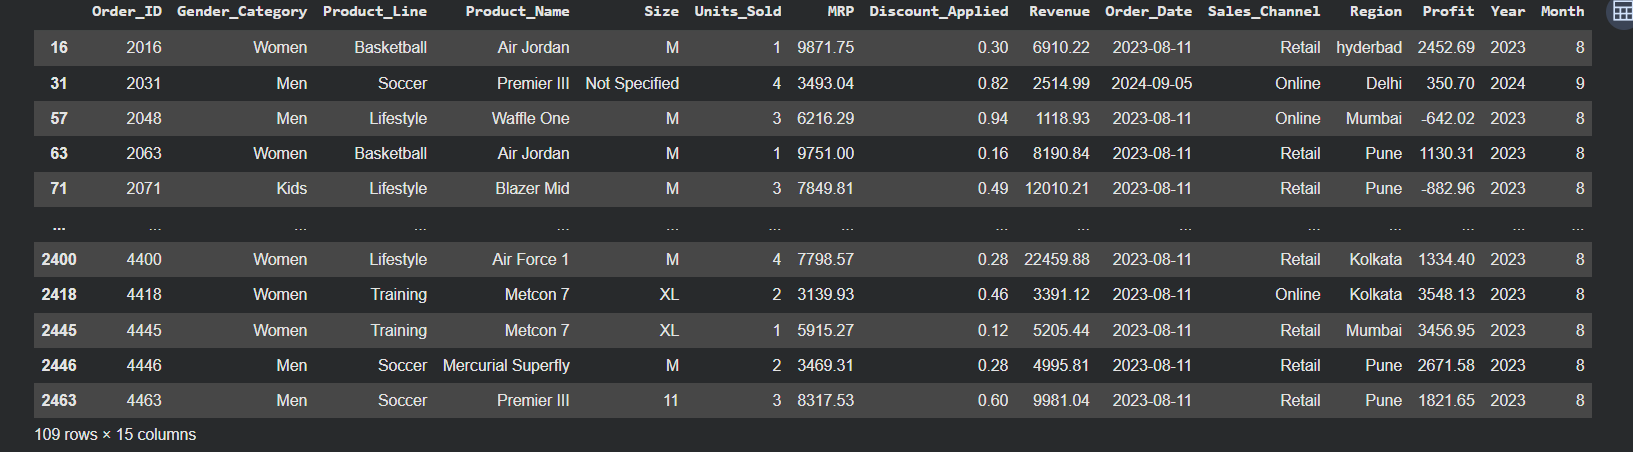

In [569]:
print(f"\n dataset: {df_clean.shape[0]} rows remaining")
df_clean.info()
df_clean.head(-1)


 dataset: 110 rows remaining
<class 'pandas.core.frame.DataFrame'>
Index: 110 entries, 16 to 2484
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          110 non-null    int64         
 1   Gender_Category   110 non-null    object        
 2   Product_Line      110 non-null    object        
 3   Product_Name      110 non-null    object        
 4   Size              110 non-null    object        
 5   Units_Sold        110 non-null    int64         
 6   MRP               110 non-null    float64       
 7   Discount_Applied  110 non-null    float64       
 8   Revenue           110 non-null    float64       
 9   Order_Date        110 non-null    datetime64[ns]
 10  Sales_Channel     110 non-null    object        
 11  Region            110 non-null    object        
 12  Profit            110 non-null    float64       
 13  Year              110 non-null    int64         
 14 

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit,Year,Month
16,2016,Women,Basketball,Air Jordan,M,1,9871.75,0.30,6910.22,2023-08-11,Retail,hyderbad,2452.69,2023,8
31,2031,Men,Soccer,Premier III,Not Specified,4,3493.04,0.82,2514.99,2024-09-05,Online,Delhi,350.70,2024,9
57,2048,Men,Lifestyle,Waffle One,M,3,6216.29,0.94,1118.93,2023-08-11,Online,Mumbai,-642.02,2023,8
63,2063,Women,Basketball,Air Jordan,M,1,9751.00,0.16,8190.84,2023-08-11,Retail,Pune,1130.31,2023,8
71,2071,Kids,Lifestyle,Blazer Mid,M,3,7849.81,0.49,12010.21,2023-08-11,Retail,Pune,-882.96,2023,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2400,4400,Women,Lifestyle,Air Force 1,M,4,7798.57,0.28,22459.88,2023-08-11,Retail,Kolkata,1334.40,2023,8
2418,4418,Women,Training,Metcon 7,XL,2,3139.93,0.46,3391.12,2023-08-11,Online,Kolkata,3548.13,2023,8
2445,4445,Women,Training,Metcon 7,XL,1,5915.27,0.12,5205.44,2023-08-11,Retail,Mumbai,3456.95,2023,8
2446,4446,Men,Soccer,Mercurial Superfly,M,2,3469.31,0.28,4995.81,2023-08-11,Retail,Pune,2671.58,2023,8


In [570]:

df_clean.head(-1)

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit,Year,Month
16,2016,Women,Basketball,Air Jordan,M,1,9871.75,0.30,6910.22,2023-08-11,Retail,hyderbad,2452.69,2023,8
31,2031,Men,Soccer,Premier III,Not Specified,4,3493.04,0.82,2514.99,2024-09-05,Online,Delhi,350.70,2024,9
57,2048,Men,Lifestyle,Waffle One,M,3,6216.29,0.94,1118.93,2023-08-11,Online,Mumbai,-642.02,2023,8
63,2063,Women,Basketball,Air Jordan,M,1,9751.00,0.16,8190.84,2023-08-11,Retail,Pune,1130.31,2023,8
71,2071,Kids,Lifestyle,Blazer Mid,M,3,7849.81,0.49,12010.21,2023-08-11,Retail,Pune,-882.96,2023,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2400,4400,Women,Lifestyle,Air Force 1,M,4,7798.57,0.28,22459.88,2023-08-11,Retail,Kolkata,1334.40,2023,8
2418,4418,Women,Training,Metcon 7,XL,2,3139.93,0.46,3391.12,2023-08-11,Online,Kolkata,3548.13,2023,8
2445,4445,Women,Training,Metcon 7,XL,1,5915.27,0.12,5205.44,2023-08-11,Retail,Mumbai,3456.95,2023,8
2446,4446,Men,Soccer,Mercurial Superfly,M,2,3469.31,0.28,4995.81,2023-08-11,Retail,Pune,2671.58,2023,8


## Fix Typos in regions

In [571]:
# Typos in regions
df_clean['Region'].unique()

corrections = {
    'bengaluru': 'Bangalore',
    'hyderbadc': 'Hyderabad',
    'hyderbad':'Hyderabad',
     'Hyd':'Hyderabad'
}
df_clean['Region'] = df['Region'].replace(corrections)
df_clean['Region'].unique()


array(['Hyderabad', 'Delhi', 'Mumbai', 'Pune', 'Bangalore', 'Kolkata'],
      dtype=object)

In [572]:
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 110 entries, 16 to 2484
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          110 non-null    int64         
 1   Gender_Category   110 non-null    object        
 2   Product_Line      110 non-null    object        
 3   Product_Name      110 non-null    object        
 4   Size              110 non-null    object        
 5   Units_Sold        110 non-null    int64         
 6   MRP               110 non-null    float64       
 7   Discount_Applied  110 non-null    float64       
 8   Revenue           110 non-null    float64       
 9   Order_Date        110 non-null    datetime64[ns]
 10  Sales_Channel     110 non-null    object        
 11  Region            110 non-null    object        
 12  Profit            110 non-null    float64       
 13  Year              110 non-null    int64         
 14  Month             110 non-nul

In [573]:
# Statistical summary
df_clean.describe(include='all')

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit,Year,Month
count,110.000000,110,110,110,110,110.000000,110.000000,110.000000,110.000000,110,110,110,110.000000,110.000000,110.000000
unique,NaN,3,5,20,11,NaN,NaN,NaN,NaN,NaN,2,6,NaN,NaN,NaN
top,NaN,Men,Training,Flex Trainer,Not Specified,NaN,NaN,NaN,NaN,NaN,Retail,Kolkata,NaN,NaN,NaN
freq,NaN,41,29,11,27,NaN,NaN,NaN,NaN,NaN,57,21,NaN,NaN,NaN
mean,3183.109091,NaN,NaN,NaN,NaN,2.390909,5998.959273,0.457273,7284.846909,2023-08-28 10:15:16.363636480,NaN,NaN,1274.430364,2023.063636,7.818182
min,2003.000000,NaN,NaN,NaN,NaN,1.000000,2068.950000,0.010000,236.320000,2023-03-09 00:00:00,NaN,NaN,-1152.860000,2023.000000,3.000000
25%,2538.750000,NaN,NaN,NaN,NaN,1.250000,4201.837500,0.230000,3305.942500,2023-08-11 00:00:00,NaN,NaN,54.315000,2023.000000,8.000000
50%,3171.000000,NaN,NaN,NaN,NaN,2.000000,6170.740000,0.455000,5591.790000,2023-08-11 00:00:00,NaN,NaN,1311.880000,2023.000000,8.000000
75%,3793.250000,NaN,NaN,NaN,NaN,3.000000,7837.000000,0.677500,9235.067500,2023-08-11 00:00:00,NaN,NaN,2569.942500,2023.000000,8.000000
max,4484.000000,NaN,NaN,NaN,NaN,4.000000,9872.380000,0.980000,37169.350000,2025-03-01 00:00:00,NaN,NaN,3894.950000,2025.000000,9.000000


### Descriptive summary Statistics

# Univariate Analysis

##Revenue Distribution

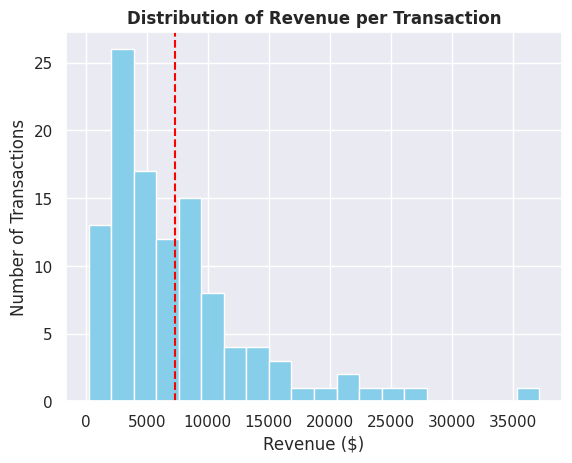

In [574]:
plt.hist(df_clean['Revenue'], bins=20, color='skyblue')
plt.title('Distribution of Revenue per Transaction', fontsize=12, fontweight='bold')
plt.xlabel('Revenue ($)')
plt.ylabel('Number of Transactions')
plt.axvline(df_clean['Revenue'].mean(), color='red', linestyle='--', label=f'Mean: ${df_clean["Revenue"].mean():.0f}')
plt.show()

Most transactions fall in the range of 5000- 10000, with fewer high-value sales above 20000. The distribution is right-skewed, showing normal sales are mid range, not very low or very high

##Units Distribution

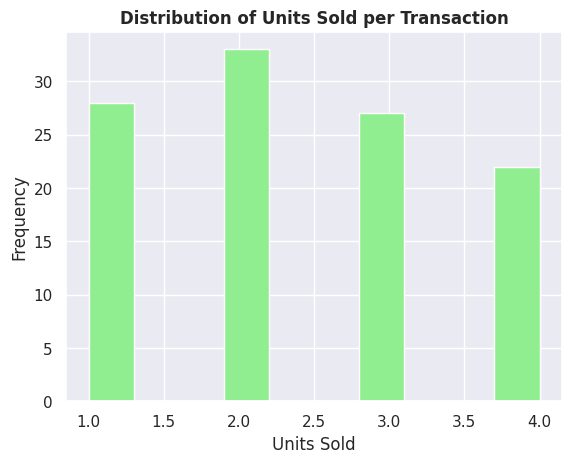

In [575]:
plt.hist(df_clean['Units_Sold'], color='lightgreen')
plt.title('Distribution of Units Sold per Transaction', fontsize=12, fontweight='bold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')

plt.show()

Most transactions have 1-4 units per order, with 2 units being most common. showing customers typically buy 2-3 items per transaction.


##Gender Revenue

,Revenue
Gender_Category,
Kids,228266.29
Men,310701.44
Women,262365.43


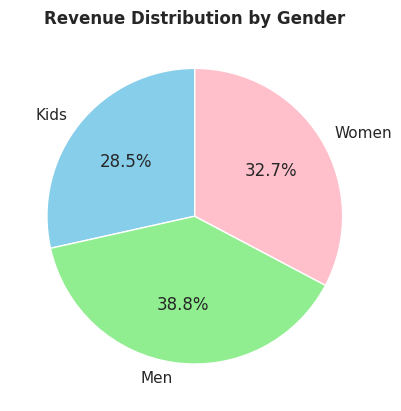

In [576]:
gender_revenue = df_clean.groupby('Gender_Category')['Revenue'].sum()
colors = ['skyblue', 'lightgreen', 'pink']
plt.pie(gender_revenue, labels=gender_revenue.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Revenue Distribution by Gender', fontsize=12, fontweight='bold')
gender_revenue

Men generate the highest revenue at 38.8% , followed closely by Women at 32.7% , and Kids at 28.5% .The distribution is balanced across the three categories

# Bivariate Analysis

##Product Line Revenue

,Revenue
Product_Line,
Running,94609.75
Soccer,147298.39
Basketball,168381.68
Lifestyle,179814.05
Training,211229.29


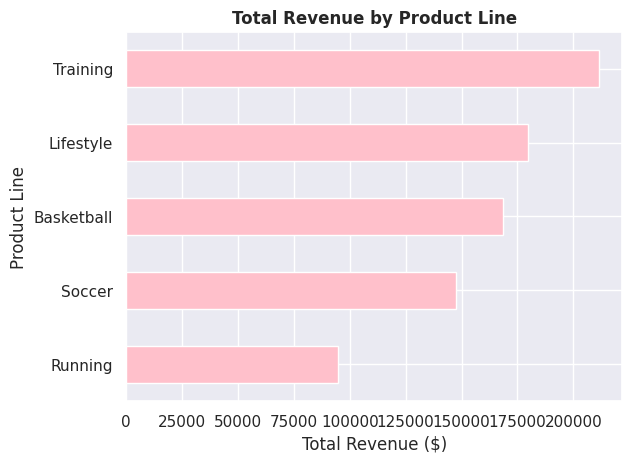

In [577]:
product_revenue = df_clean.groupby('Product_Line')['Revenue'].sum().sort_values()
product_revenue.plot(kind='barh', color='pink')
plt.title('Total Revenue by Product Line', fontsize=12, fontweight='bold')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product Line')
product_revenue

Training generates the highest revenue at 211,229, and Running contribute the least at 94,610.
Training products are the top performer

##Discount vs Revenue

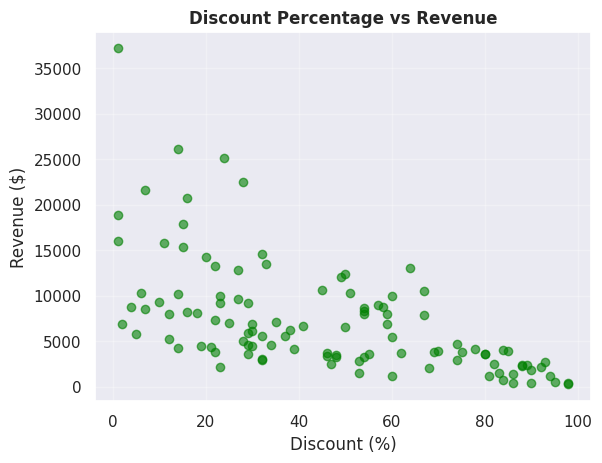

In [578]:
plt.scatter(df_clean['Discount_Applied'] * 100, df_clean['Revenue'],
            alpha=0.6, color='green')
plt.title('Discount Percentage vs Revenue', fontsize=12, fontweight='bold')
plt.xlabel('Discount (%)')
plt.ylabel('Revenue ($)')
plt.grid(True, alpha=0.3)


The scatter plot shows No clear relationship between discount and revenue. discounts alone don't determine sales performance.
heavily discounted transactions generate low revenue, while full priced product get higher revenue.

##Sales Channel

,Revenue
Sales_Channel,
Online,414364.49
Retail,386968.67


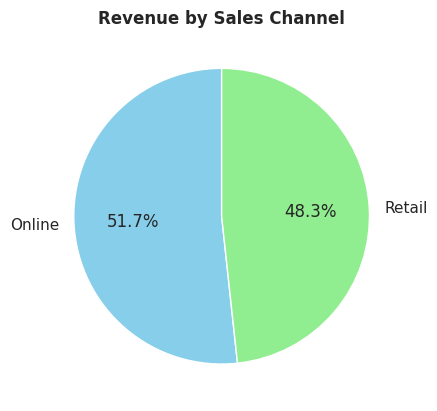

In [579]:
channel_revenue = df_clean.groupby('Sales_Channel')['Revenue'].sum()
plt.pie(channel_revenue, labels=channel_revenue.index, autopct='%1.1f%%',
        colors=['skyblue','lightgreen'] , startangle=90)
plt.title('Revenue by Sales Channel', fontsize=12, fontweight='bold')
channel_revenue

Online generates slightly higher revenuecompared to Retail.
Nike's sales are well-balanced across digital and physical stores.

##Top Products

,Revenue
Product_Name,
Flex Trainer,77067.95
LeBron 20,63676.17
Air Zoom,58144.30
Waffle One,56154.20
Zoom Freak,51500.51


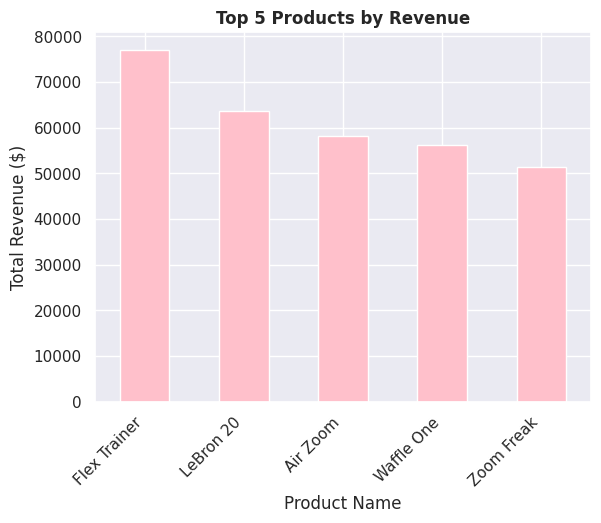

In [580]:
top_products = df_clean.groupby('Product_Name')['Revenue'].sum().nlargest(5)
top_products.plot(kind='bar', color='pink')
plt.title('Top 5 Products by Revenue', fontsize=12, fontweight='bold')
plt.xlabel('Product Name')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45, ha='right')
top_products

Flex Trainer best selling product in revenue, and Zoom Freak contribute the least. indicating clear product performance differences. Training shoes leading the revenue

## Revenue by Region

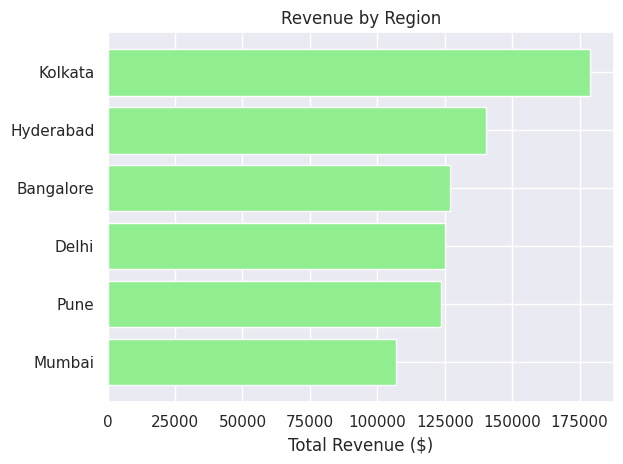

In [581]:
region_revenue = df_clean.groupby('Region')['Revenue'].sum().sort_values()
plt.barh(region_revenue.index, region_revenue.values, color='lightgreen')
plt.title('Revenue by Region')
plt.xlabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

Kolkata generates the highest revenue, followed by Hyderabad. Bangalore, Dehli and Pine Almost equall, Lastly Mumbai. Performance varies significantly across cities

# Time-Based Analysis

##Monthly Trend

,Revenue
Month,
3,15613.45
4,7127.85
7,2839.18
8,773237.69
9,2514.99


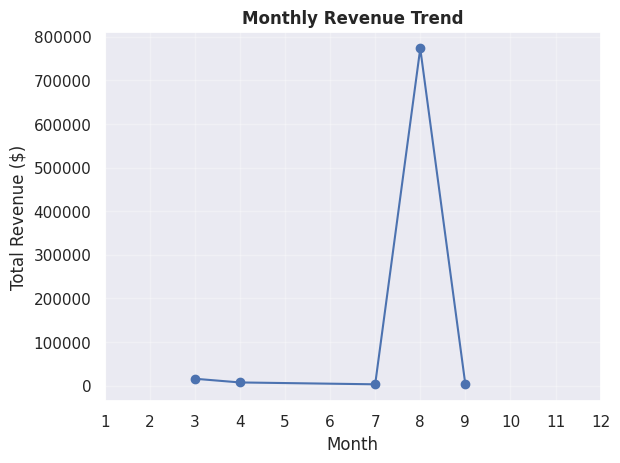

In [582]:
monthly_revenue = df_clean.groupby('Month')['Revenue'].sum()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')
plt.title('Monthly Revenue Trend', fontsize=12, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
monthly_revenue

August shows massive revenue spike at 773,238 , while all other months have minimal sales under 16,000. This could indicate a back to school or summer promotion period. The remaining months show very low activity.

##Correlation Matrix

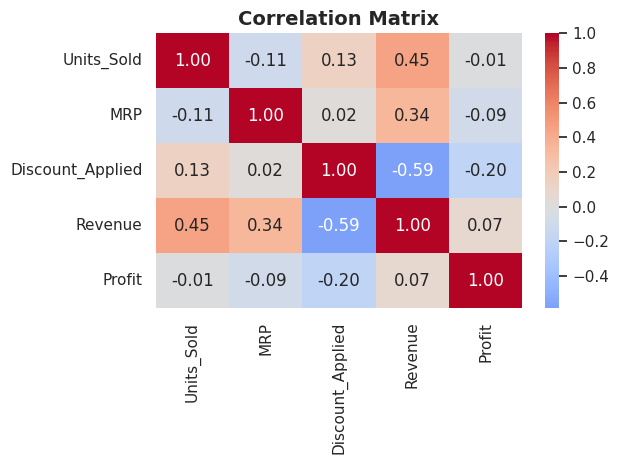

In [583]:
# Select numeric columns
numeric_cols = ['Units_Sold', 'MRP', 'Discount_Applied', 'Revenue', 'Profit']

# Create correlation matrix
corr_matrix = df_clean[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Insights from correlation matrix:

close to +1 = strong positive relationship
as shown, Revenue and Units_Soldhave a moderate positive relationship. More units sold leads to higher revenue

close to -1 = strong negative relationship
Revenue and Discount_Applied have a moderate negative relationship. Higher discounts result in lower revenue.

close to 0 = no relationship
MRP has weak relationship with all variables same as profit
Profit shows almost no correlation with anything
Units_Sold and MRP practically no relationship

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file
2. Dataset Description readme file
2. Jupyter Notebook
